Reachability deficit of GM-QAOA\
--> We need $p = 2^{n/2}$ to converge to an optimal solution.\
Here we implement numerical experiments to find what depth p is needed to find an optimal solution.

In [45]:
"""
Title: Benchmarking GM-QAOA for MaxCut

The code was inspired by 
"Provable avoidance of barren plateaus for the Quantum Approximate Optimization Algorithm with Grover mixers."
arXiv:2509.10424
Author: Matthew Nuyten
Last Update: 1/16/2026
"""

import matplotlib.pyplot as plt
import networkx as nx
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp

import time
import itertools as it
from typing import Dict, List, Tuple
from matplotlib.ticker import LogLocator, MaxNLocator, AutoLocator

import os

## Operators

In [47]:

# ================================================================
# Hamiltonians
# ================================================================

def maxcut_hamiltonian(edges: List[Tuple[int, int]], normalize: bool = True) -> qml.Hamiltonian:
    """
    The problem Hamiltonian we want to maximize
    H_P = sum_{(i,j) in E} 0.5*(1 - Z_i Z_j) 

    normalize=True, for computing the variance of the loss function.
    """
    m = len(edges)
    coeffs = []
    ops = []
    scale = 1.0 / m if (normalize and m > 0) else 1.0

    #Single global identity shift: 0.5 * m  -> coefficient (0.5*m)*scale
    if m > 0:
        coeffs.append(0.5 * m * scale)
        ops.append(qml.Identity(wires=0))  # global shift

    for (i, j) in edges:
        coeffs.append(-0.5 * scale)  # -0.5 Z_i Z_j
        ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

    return qml.Hamiltonian(coeffs, ops)

def x_mixer_hamiltonian(n_wires: int) -> qml.Hamiltonian:
    """Return the standard QAOA mixer Hamiltonian:
    Transverse field mixer, X-mixer, H = sum_i X_i."""
    
    coeffs = [1.0] * n_wires
    ops = [qml.PauliX(i) for i in range(n_wires)]
    return qml.Hamiltonian(coeffs, ops)

# ================================================================
# Grover Mixer
# ================================================================

def phase_on_zero_state(beta, wires):
    controls = wires[:-1]
    target = wires[-1]
    for w in wires:
        # apply flip   
        qml.PauliX(wires=w)
    # Apply a multi-controlled PhaseShift of e^{-i*beta} on the last qubit
    qml.ctrl(qml.PhaseShift, control=controls)(-2*beta, target)
    for w in wires:
        # Undo flip
        qml.PauliX(wires=w)

def grover_mixer_unitary(beta, wires):
    """Apply Grover mixer U_M(beta) = H^{⊗n} * exp(-i beta |0^n><0^n|) * H^{⊗n}."""
    for w in wires:
        qml.Hadamard(wires=w)
    phase_on_zero_state(beta, wires)
    for w in wires:
        qml.Hadamard(wires=w)


In [49]:
def maxcut_hamiltonian(edges: List[Tuple[int, int]], normalize: bool = True) -> qml.Hamiltonian:
    """
    The problem Hamiltonian we want to maximize
    H_P = sum_{(i,j) in E} Z_i Z_j 

    normalize=True, for computing the variance of the loss function.
    """
    m = len(edges)
    coeffs = []
    ops = []
    #scale = 1.0 / m if (normalize and m > 0) else 1.0

    for (i, j) in edges:
        coeffs.append(1.0)  # 1.0 * Z_i Z_j
        ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

    return qml.Hamiltonian(coeffs, ops)

## Circuit

In [51]:
# ================================================================
# QAOA Circuit
# ================================================================

def qaoa_layer(gamma, beta, cost_h, mixer, n_wires):
    qml.ApproxTimeEvolution(cost_h, gamma, 1)

    if mixer == "standard":
        qml.ApproxTimeEvolution(
            x_mixer_hamiltonian(n_wires), beta, 1
        )
    elif mixer == "grover":
        grover_mixer_unitary(beta, wires=list(range(n_wires)))
    else:
        raise ValueError(f"Unknown mixer: {mixer}")

def qaoa_circuit(
    gammas,
    betas,
    cost_h,
    mixer,
    n_wires,
):
    
    for w in range(n_wires):
        qml.Hadamard(wires=w)

    for gamma, beta in zip(gammas, betas):
        qaoa_layer(gamma, beta, cost_h, mixer, n_wires)


## Benchmarking

In [53]:
# ================================================================
# MaxCut approximation ratio
# ================================================================

def cut_value(
    bitstring: Tuple[int, ...],
    edges: List[Tuple[int, int]],
    weights: Dict[Tuple[int, int], float] = None,
):
    """Compute the cut value for a given bitstring for weighted or unweighted graphs."""
    val = 0.0
    for i, j in edges:
        if bitstring[i] != bitstring[j]:
            w = 1.0 if weights is None else weights[(i, j)]
            val += w
    return val

def max_cut_value(
    n: int,
    edges: List[Tuple[int, int]],
    weights: Dict[Tuple[int, int], float] = None,
):
    """
    Compute the maximum cut value and all optimal bitstrings.

    Returns:
        max_value: float
        optimal_bitstrings: list of tuples
    """
    max_value = float("-inf")
    optimal_bitstrings = []

    for z in it.product([0, 1], repeat=n):
        val = cut_value(z, edges, weights)

        if val > max_value:
            max_value = val
            optimal_bitstrings = [z]
        elif val == max_value:
            optimal_bitstrings.append(z)

    return max_value, optimal_bitstrings

In [75]:
def qaoa_approximation_ratio(
    n_wires,
    edges,
    max_depth=5,
    mixer="grover",
    optimizer_name="adam",
    steps=100,
    stepsize=0.02,
    device_name="lightning.qubit",
    gamma_range=(0.0, 2*np.pi),
    beta_range=(0.0, np.pi),
    seed=None,
):
    rng = np.random.default_rng(seed)

    # Exact Max-Cut value
    C_max, _ = max_cut_value(n_wires, edges)

    cost_h = maxcut_hamiltonian(edges)
    dev = qml.device(device_name, wires=n_wires)

    @qml.qnode(dev)
    def cost_circuit(gammas, betas):
        qaoa_circuit(gammas, betas, cost_h, mixer, n_wires)
        return qml.expval(cost_h)

    results = {}

    for p in range(1, max_depth + 1):

        # optimizer per depth
        if optimizer_name.lower() == "adam":
            opt = qml.AdamOptimizer(stepsize)
        elif optimizer_name.lower() == "gd":
            opt = qml.GradientDescentOptimizer(stepsize)
        else:
            raise ValueError("Unknown optimizer")

        # initialize parameters
        init_gammas = rng.uniform(*gamma_range, size=p)
        init_betas  = rng.uniform(*beta_range, size=p)

        gammas = pnp.array(init_gammas, requires_grad=True)
        betas  = pnp.array(init_betas,  requires_grad=True)

        t0 = time.time()

        def cost_fn(g, b):
            return cost_circuit(g, b)

        for _ in range(steps):
            gammas, betas = opt.step(cost_fn, gammas, betas)

        opt_value = - float(cost_circuit(gammas, betas))
        approx_ratio = opt_value / C_max

        t1 = time.time()

        results[p] = {
            "approx_ratio": approx_ratio,
            "opt_value": opt_value,
            "time": t1 - t0,
        }

    return results


In [11]:
# Example
G = nx.Graph()
G.add_edges_from([(0, 1), (0,2), (1, 2), (1,3), (2, 4), (3,4)]) #House Graph
n_wires = G.number_of_nodes()
edges = G.edges()

qaoa_approximation_ratio(
    n_wires,
    edges,
    max_depth=5,
    mixer="grover",
    optimizer_name="adam",
    steps=100,
    stepsize=0.02,
    device_name="default.qubit",
    gamma_range=(0.0, 2*np.pi),
    beta_range=(0.0, np.pi),
    seed=1234,
)

{1: {'approx_ratio': 0.35590295033854635,
  'opt_value': 1.7795147516927319,
  'time': 0.7098760604858398},
 2: {'approx_ratio': 0.39723183822861985,
  'opt_value': 1.9861591911430994,
  'time': 1.0820212364196777},
 3: {'approx_ratio': 0.6036283913609967,
  'opt_value': 3.018141956804983,
  'time': 1.4326632022857666},
 4: {'approx_ratio': 0.7425660820673765,
  'opt_value': 3.7128304103368825,
  'time': 1.824794054031372},
 5: {'approx_ratio': 0.7618686035429173,
  'opt_value': 3.8093430177145864,
  'time': 2.1809117794036865}}

In [12]:
# Example
G = nx.Graph()
G.add_edges_from([(0, 1), (0,2), (1, 2), (1,3), (2, 4), (3,4)]) #House Graph
n_wires = G.number_of_nodes()
edges = G.edges()

qaoa_approximation_ratio(
    n_wires,
    edges,
    max_depth=5,
    mixer="grover",
    optimizer_name="adam",
    steps=100,
    stepsize=0.02,
    device_name="default.qubit",
    gamma_range=(0.0, 2*np.pi),
    beta_range=(0.0, np.pi),
    seed=1234,
)

{1: {'approx_ratio': 0.35590295033854635,
  'opt_value': 1.7795147516927319,
  'time': 0.6002240180969238},
 2: {'approx_ratio': 0.39723183822861985,
  'opt_value': 1.9861591911430994,
  'time': 1.014526128768921},
 3: {'approx_ratio': 0.6036283913609967,
  'opt_value': 3.018141956804983,
  'time': 1.3650968074798584},
 4: {'approx_ratio': 0.7425660820673765,
  'opt_value': 3.7128304103368825,
  'time': 1.7966740131378174},
 5: {'approx_ratio': 0.7618686035429173,
  'opt_value': 3.8093430177145864,
  'time': 2.177402973175049}}

### Checkpoint 1 - Approximation Ratio
1) Find the approximation ratio $\alpha = \langle H_C \rangle / C_{\text{max}}$ for GM-QAOA for a few sample graphs.
2) How does $\alpha$ change for increased depth $p$? How about graph size $n$?

In [57]:
def sample_random_graph(n_wires: int, seed: int | None = None) -> List[Tuple[int, int]]:
    """Generate a random connected graph with n_wires nodes and return list of edges."""
    rng = np.random.default_rng(seed)
    while True:
        G = nx.gnp_random_graph(n_wires, seed=int(rng.integers(0, 1000)), p=0.5)
        if nx.is_connected(G):
            return list(G.edges())

#### Random Graphs Experiment

In [22]:
# Define parameters
n_wires = 5
seed = 1234
edges = sample_random_graph(n_wires, seed)
alpha = qaoa_approximation_ratio(n_wires, edges)

In [23]:
import pandas as pd
df = pd.DataFrame(alpha)

In [24]:
df

,1,2,3,4,5
approx_ratio,0.020783,0.038489,0.444549,0.038647,0.705337
opt_value,0.083131,0.153955,1.778197,0.154586,2.821350
time,0.582682,0.888643,1.202201,1.759999,1.956591


In [61]:
def random_graph_experiment(
    n_min: int,
    n_max: int,
    max_depth: int,
    seed: int,
    **qaoa_kwargs,
):
    """
    For n = n_min,...,n_max:
        - sample random graph
        - compute QAOA approximation ratio vs depth

    Returns:
        results[n][p] = approx_ratio
    """
    rng = np.random.default_rng(seed)
    results = {}

    for n in range(n_min, n_max + 1):
        edges = sample_random_graph(n, seed=rng.integers(1e9))

        # Compute exact Max-Cut value and bitstring
        C_max, _ = max_cut_value(n, edges)
        

        print(f"Running QAOA for n={n}, |E|={len(edges)}, C_max={C_max}")

        qaoa_res = qaoa_approximation_ratio(
            n,
            edges,
            max_depth=max_depth,
            seed=rng.integers(1e9),
            **qaoa_kwargs,
        )
        optimal_expval = max([qaoa_res[p]["opt_value"] for p in qaoa_res])
        print("expectation value <H_C>", optimal_expval)
        # Extract approximation ratios by depth
        results[n] = {
            "C_max": C_max,
            "expval": optimal_expval,
            "edges": edges,
            "ratios": {
                p: qaoa_res[p]["approx_ratio"]
                for p in qaoa_res
            },
        }
        
    return results

In [85]:
# Example - GM-QAOA + adam
results = random_graph_experiment(
    n_min=3,
    n_max=5,
    max_depth=20,
    mixer="grover",
    optimizer_name="adam",
    steps=100,
    stepsize=0.01,
    seed=41
)

Running QAOA for n=3, |E|=2, C_max=2.0
expectation value <H_C> 1.9999988758907767
Running QAOA for n=4, |E|=3, C_max=3.0
expectation value <H_C> 2.999991920573372
Running QAOA for n=5, |E|=4, C_max=4.0
expectation value <H_C> 3.999985926836193


In [87]:
import itertools as it

def plot_approx_ratio_vs_depth(results, gw_ratio=0.87856):
    plt.figure(figsize=(8, 5))
    
    marker_styles = it.cycle(['H','D','X','P','v','*','+', 'p', 's', 'o'])
    
    for n, data in results.items():
        ratios_dict = data["ratios"]
        depths = sorted(ratios_dict.keys())
        ratios = [ratios_dict[p] for p in depths]
        current_marker = next(marker_styles)
        
        plt.plot(
            depths,
            ratios,
            marker=current_marker,
            label=f"n={n}, max_ratio: {round(max(ratios),4)}",
        )

    plt.axhline(
        y=gw_ratio,
        linestyle="--",
        linewidth=2,
        color="black",
        label="GW (0.87856)",
    )

    plt.xlabel("QAOA depth $p$")
    plt.ylabel("Approximation ratio")
    plt.title("QAOA Max-Cut Approximation Ratio vs Depth")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


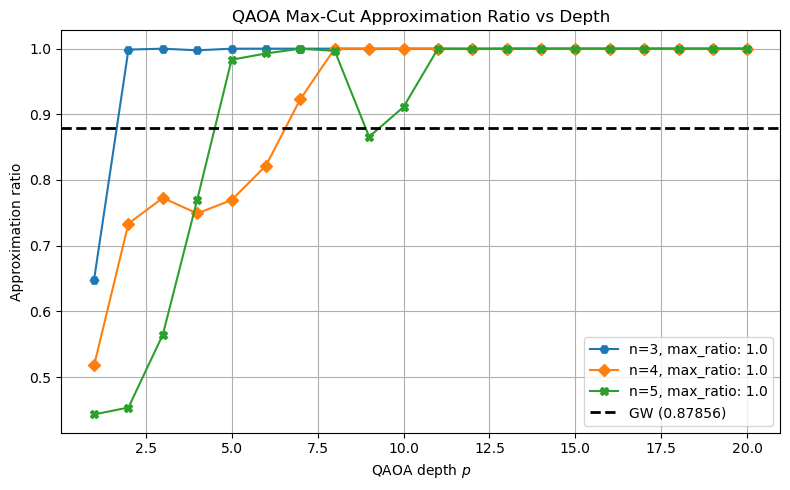

In [89]:
plot_approx_ratio_vs_depth(results)

The above results show that the approximation ration $\alpha$ is likely to decrease as the number of QAOA layers increases. The optimal parameters are found at each layer, done in a succession of steps-- based on Adaptive Moment Estimation (Adam).\
Questions:
1. Is this what we would expect for the ratio vs depth plot?
2. If not, why would we expect it to increase as the depth increases?

### Experiments ran on HPC

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
### Import .csv file containing variance/expectation/time vs depth(column) vs graph(row) data
df = pd.read_csv('benchmark_depth40_out.csv')

In [24]:
df

,9,10,11,12,13,14,15
0,13.0,17.0,19.0,17.0,31.0,34.0,36.0
1,9.308932966142748,8.418275928242348,10.200877450450399,10.159972293809416,12.4111633787965,11.824638469958126,12.383944325663434
2,"[(0, 6), (0, 7), (1, 3), (1, 6), (1, 7), (2, 5...","[(0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 8...","[(0, 1), (0, 3), (0, 4), (0, 5), (0, 7), (0, 9...","[(0, 2), (0, 3), (0, 7), (1, 8), (2, 7), (2, 8...","[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7...","[(0, 1), (0, 2), (0, 4), (0, 5), (0, 7), (0, 8...","[(0, 1), (0, 3), (0, 5), (0, 6), (0, 7), (0, 8..."
3,"{1: 0.002251937637393735, 2: 0.004744001908768...","{1: 0.0006675120860258184, 2: -3.8906102974236...","{1: 0.003381709404090111, 2: 0.252427724841195...","{1: 0.0001477906999936438, 2: 0.18835362976276...","{1: 0.00014788639742913535, 2: 0.1263480533119...","{1: 5.804749616787262e-05, 2: 2.34554803803099...","{1: 9.815480492082288e-06, 2: 2.42332078582072..."


In [26]:
import ast 
# Apply literal_eval to each column
# Only need to do once.
for col in df.columns:
    df[col] = df[col].apply(ast.literal_eval)

In [28]:
# Interpreting the dataframe
for col in df.columns:
    ratios = df[col][3] 
    #df[col][0] returns the exact maxcut value, df[col][1] returns the qaoa expected value, df[col][2] returns graph edges 
    print(f"Approximation ratios for random graph with {col} vertices:")
    for depth in ratios.keys():
        print(f"ratio at depth {depth}: {ratios[depth]}.")

Approximation ratios for random graph with 9 vertices:
ratio at depth 1: 0.002251937637393735.
ratio at depth 2: 0.00474400190876885.
ratio at depth 3: 0.3185263609528456.
ratio at depth 4: 0.21898896022902697.
ratio at depth 5: 0.44866502100934846.
ratio at depth 6: 0.4302605701810602.
ratio at depth 7: 0.39145773448328075.
ratio at depth 8: 0.3175759013044598.
ratio at depth 9: 0.5147700013195566.
ratio at depth 10: 0.2286577420642941.
ratio at depth 11: 0.58084342637686.
ratio at depth 12: 0.4390806002251954.
ratio at depth 13: 0.5484693881089415.
ratio at depth 14: 0.613216389635535.
ratio at depth 15: 0.5984939154155434.
ratio at depth 16: 0.4975534959043842.
ratio at depth 17: 0.5807314430359927.
ratio at depth 18: 0.5892277485819041.
ratio at depth 19: 0.6566382448124629.
ratio at depth 20: 0.6185242918142968.
ratio at depth 21: 0.5554993361950828.
ratio at depth 22: 0.6484348467028546.
ratio at depth 23: 0.6332821978217926.
ratio at depth 24: 0.5869511933341062.
ratio at depth 

In [30]:

def plot_approx_ratio_vs_depth(results):
    plt.figure(figsize=(8, 5))
    
    marker_styles = it.cycle(['H','D','X','P','v','*','+', 'p', 's', 'o'])

    # reference - Goemans and Williamson
    gw_ratio=0.87856
    
    for n, data in results.items():
        ratios_dict = data[3] #select data for "ratios" dict
        depths = list(ratios_dict.keys())
        ratios = [ratios_dict[depth] for depth in depths]
        current_marker = next(marker_styles)
        
        plt.plot(
            depths,
            ratios,
            marker=current_marker,
            label=f"n={n}, max_ratio: {round(max(ratios),5)}",
        )

    plt.axhline(
        y=gw_ratio,
        linestyle="--",
        linewidth=2,
        color="black",
        label="0.87856",
    )

    plt.xlabel("QAOA depth $p$")
    #plt.xticks([1, 2, 3, 4, 5])
    plt.ylabel("Approximation ratio")
    plt.title("GM-QAOA Max-Cut Approximation Ratio vs Depth")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


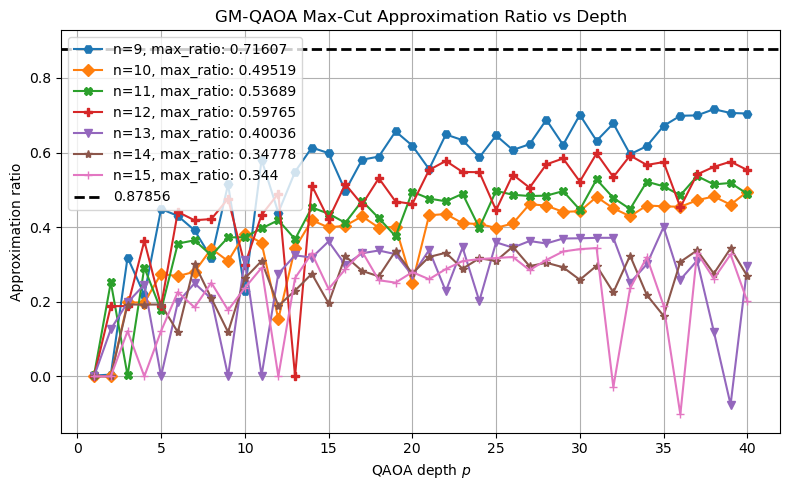

In [32]:
plot_approx_ratio_vs_depth(df)